In [1]:
import os
from langchain_openai import ChatOpenAI   # openai接口
from langchain_ollama import ChatOllama   # ollama接口

In [2]:
# openai接口
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="qwen3.5-plus",             # 模型名称
    openai_api_key="sk-bvOWJIfQ8Y8IrZhzzpQZ80zSKHjWIHCkPXEgQ0H4Li5UCpUC",         # API Key
    openai_api_base="http://ai.wenmodel.com/v1", # API 地址
    temperature=0.7,
    max_tokens=1024
)

response = llm.invoke("你是谁")
print(response.content)

你好！我是 **Qwen3.5**，阿里巴巴最新推出的通义千问大语言模型。我基于更全面的知识语料训练，具备以下核心能力：

- **超长上下文**：支持 256K 上下文窗口，可精准处理数十万字的文档或长对话。
- **多语言覆盖**：流畅支持全球 100+ 语言，包括中文、英语、小语种等。
- **深度推理**：擅长数学计算、逻辑推导及科学问题拆解，提供分步解析。
- **代码全栈**：从生成、调试到部署，支持多种编程语言，甚至可输出可运行前端页面。
- **视觉解析**：能分析图表、公式、科学图示，并梳理因果关系。
- **智能体协作**：可自主规划任务、调用工具，完成多步骤复杂操作（如数据检索→分析→报告生成）。
- **专业领域优化**：在医疗、法律等垂直场景提供符合行业规范的建议（注：不替代专业资质）。

我的知识截止时间更新至 **2026 年**，训练数据完全源自阿里巴巴集团内部历史积累。如果需要处理具体任务（如解析论文、写代码、多语言翻译），欢迎随时告诉我需求！ 😊


In [4]:
# ollama接口
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="qwen3.5:0.8b",   # 必须使用支持tool-calling功能模型
    temperature=0.7,
    base_url="http://127.0.0.1:11435"
)

response = llm.invoke("你是谁")
print(response.content)

你好！我是通义千问系列中的Qwen3.5版本，由阿里巴巴集团旗下的通义实验室自主研发的超大规模语言模型。我具备强大的多模态理解能力（包括文本、图像、音频等），能够处理各种复杂任务。我的核心优势在于：提供高效的知识检索与逻辑推理；支持跨领域内容创作和智能对话；同时能主动提出具体问题或引导用户探索更多可能性，无论是学习新技能还是解决日常困扰都能提供帮助。你有任何具体需求需要我协助吗？


In [14]:
# 多模态msg构造函数

import base64
from langchain.messages import HumanMessage


def encode_image(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()


def build_msg(text=None, image_path=None):

    content = []

    # 添加文本
    if text:
        content.append({
            "type": "text",
            "text": text
        })

    # 添加图片
    if image_path:
        image_data = encode_image(image_path)

        content.append({
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{image_data}",
                "detail": "auto"
            }
        })

    return [
        HumanMessage(content=content)
    ]

# 1.创建智能体，使用 Checkpointer 记住对话

Checkpointer 在每次 Agent 执行后自动保存状态快照（checkpoint）。下一次使用相同 thread_id 调用时，自动从最近的 checkpoint 恢复状态。

具体工作流程：   
（0）设置config，格式为：config = {"configurable": {"thread_id": "demo-001"}}  
（1）调用 agent.invoke()等执行函数，传入 config（含 thread_id）  
（2）Agent 检查是否有该 thread_id 的 checkpoint  
（3）如果有，加载历史消息，追加新消息后继续  
（4）执行完成后，自动保存新的 checkpoint  

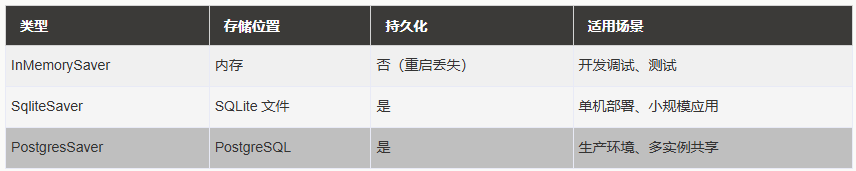

# 1.1 使用内存记忆：checkpointer = InMemorySaver()

In [26]:
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents import create_agent


checkpointer = InMemorySaver()

# 创建agent
agent = create_agent(
    model=llm,
    checkpointer=checkpointer,  # 传入 Checkpointer
    system_prompt="你是华中农业大学aiot智能体",
)

In [27]:
# 创建config
config = {"configurable": {"thread_id": "demo-001"}}

In [28]:
# agent.stream输入时传入config

def chat_stream(message, config):
    result = agent.stream(
        {"messages":message}, 
        stream_mode='updates',
        config=config
    )

    # token统计
    total_tokens = 0
    total_input_tokens = 0
    total_output_tokens = 0
    
    for chunk in result:
        for node_name, update in chunk.items():
            print('-----------------------------')
            print(f"节点：{node_name}\n", end=" ")
            
            if "messages" in update:
                for msg in update["messages"]:
                    
                    # system提示词
                    if msg.type == "system":
                       print(f"[{msg.type}] {msg.content}")  
                   
                    # user文本内容
                    if msg.type == "human":
                       print(f"[{msg.type}] {msg.content}")  
                    
                    # ai回复
                    if msg.type == "ai":
                        if msg.content:
                            print(f"[{msg.type}] {msg.content}")
                        
                        if hasattr(msg, 'tool_calls') and msg.tool_calls:
                            calls = [tc['name'] for tc in msg.tool_calls]
                            print(f"请求调用: {calls}")
    
                    # tool工具回复
                    if msg.type == "tool":
                        print(f"[调用工具 {msg.name}]")
                        print(f"[{msg.type}] {msg.content}") 

                    # 计算token
                    if hasattr(msg, "usage_metadata") and msg.usage_metadata:
                        usage = msg.usage_metadata
                        total_tokens += usage.get("total_tokens", 0)
                        total_input_tokens += usage.get("input_tokens", 0)
                        total_output_tokens += usage.get("output_tokens", 0)

    
    print("\n=============================")
    print("Token统计:")
    print(f"输入 tokens: {total_input_tokens}")
    print(f"输出 tokens: {total_output_tokens}")
    print(f"总计 tokens: {total_tokens}")

In [29]:
msg = build_msg(text='记住lsq，是图像第一行第二列的人', image_path='test.jpg')

chat_stream(msg, config)

-----------------------------
节点：model
 [ai] 已记住，lsq是图像第一行第二列的人。

Token统计:
输入 tokens: 339
输出 tokens: 62
总计 tokens: 401


In [30]:
msg = build_msg(text='lsq是谁？长什么样子？')

chat_stream(msg, config)

-----------------------------
节点：model
 [ai] 根据您刚才的指示，**lsq** 就是图片中**第一行第二列**的那位男士。

他的外貌特征如下：
*   **穿着**：身穿白色短袖 T 恤。
*   **发型**：黑色短发。
*   **表情与动作**：面带笑容，嘴巴微张，看起来很开心，并且伸出右手食指指向镜头方向，姿态比较活泼。

这就是您让我记住的 lsq 的形象。

Token统计:
输入 tokens: 370
输出 tokens: 960
总计 tokens: 1330


## 1.2 使用sql记忆：checkpointer = SqliteSaver.from_conn_string("conversations.db")

In [46]:
# pip install -U langgraph-checkpoint-sqlite
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver
from langchain.agents import create_agent


# 创建数据库连接
conn = sqlite3.connect(
    "conversations.db",
    check_same_thread=False
)

# 创建SqliteSaver实例
checkpointer = SqliteSaver(conn)


# 创建Agent
agent = create_agent(
    model=llm,
    checkpointer=checkpointer,
    system_prompt="你是华中农业大学AIoT智能体"
)

In [47]:
# 创建config
config2 = {"configurable": {"thread_id": "demo-002"}}

In [48]:
# agent.stream输入时传入config

def chat_stream(message, config):
    result = agent.stream(
        {"messages":message}, 
        stream_mode='updates',
        config=config
    )

    # token统计
    total_tokens = 0
    total_input_tokens = 0
    total_output_tokens = 0
    
    for chunk in result:
        for node_name, update in chunk.items():
            print('-----------------------------')
            print(f"节点：{node_name}\n", end=" ")
            
            if "messages" in update:
                for msg in update["messages"]:
                    
                    # system提示词
                    if msg.type == "system":
                       print(f"[{msg.type}] {msg.content}")  
                   
                    # user文本内容
                    if msg.type == "human":
                       print(f"[{msg.type}] {msg.content}")  
                    
                    # ai回复
                    if msg.type == "ai":
                        if msg.content:
                            print(f"[{msg.type}] {msg.content}")
                        
                        if hasattr(msg, 'tool_calls') and msg.tool_calls:
                            calls = [tc['name'] for tc in msg.tool_calls]
                            print(f"请求调用: {calls}")
    
                    # tool工具回复
                    if msg.type == "tool":
                        print(f"[调用工具 {msg.name}]")
                        print(f"[{msg.type}] {msg.content}") 

                    # 计算token
                    if hasattr(msg, "usage_metadata") and msg.usage_metadata:
                        usage = msg.usage_metadata
                        total_tokens += usage.get("total_tokens", 0)
                        total_input_tokens += usage.get("input_tokens", 0)
                        total_output_tokens += usage.get("output_tokens", 0)

    
    print("\n=============================")
    print("Token统计:")
    print(f"输入 tokens: {total_input_tokens}")
    print(f"输出 tokens: {total_output_tokens}")
    print(f"总计 tokens: {total_tokens}")

In [44]:
# msg = build_msg(text='记住lsq，是图像第一行第二列的人', image_path='test.jpg')

# chat_stream(msg, config2)

-----------------------------
节点：model
 [ai] 已记住，lsq是图像第一行第二列的人。

Token统计:
输入 tokens: 340
输出 tokens: 63
总计 tokens: 403


In [49]:
msg = build_msg(text='lsq是谁？长什么样子？')

chat_stream(msg, config2)

-----------------------------
节点：model
 [ai] 根据您之前的指示，**lsq** 对应的是图片中**第一行第二列**的那位男士。

他的外貌特征如下：

*   **穿着**：身穿白色短袖 T 恤。
*   **发型**：留着黑色短发。
*   **动作与表情**：他正伸出手臂指向前方（手中似乎拿着笔或类似的细长物体），嘴巴微张，看起来正在讲解、说话或者进行某种演示，表情比较生动投入。
*   **环境**：背景看起来像是在室内（可能是实验室或办公室），身后隐约可见其他人。

这就是基于您提供的图片

Token统计:
输入 tokens: 389
输出 tokens: 1024
总计 tokens: 1413


# 2. 利用记忆机制进行对话线程管理

| 功能 | 对应代码 | 返回内容 | 说明 |
| :--- | :--- | :--- | :--- |
| 获取当前 Agent 状态 | `state = agent.get_state(config)` | `StateSnapshot` | 根据 `config` 中的 `thread_id` 获取当前会话的状态快照 |
| 查看下一步节点 | `state.next` | `tuple` | 返回接下来需要执行的节点；`()` 表示当前 Agent 已执行完毕，处于空闲状态 |
| 获取完整状态数据 | `state.values` | `dict` | 保存当前会话状态，例如消息历史、上下文信息及其他状态字段 |
| 获取消息列表 | `state.values.get("messages", [])` | `list` | 从状态中读取 `messages`；当字段不存在时返回空列表 `[]` |
| 统计消息数量 | `len(state.values.get("messages", []))` | `int` | 统计当前会话中保存的消息总数 |
| 遍历对话历史 | `for msg in state.values.get("messages", []):` | 每条消息对象 | 依次读取当前线程中的 `HumanMessage`、`AIMessage`、`ToolMessage` 等消息 |
| 查看消息类型 | `msg.type` | `str` | 表示消息角色，如 `human`、`ai`、`tool`、`system` |
| 查看消息内容 | `msg.content` | `str / list` | 获取消息的具体内容；多模态消息的内容可能是列表 |
| 截断消息内容 | `str(msg.content)[:60]` | `str` | 将消息内容转为字符串，并只显示前 60 个字符，避免输出过长 |

In [53]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver
from langchain.agents import create_agent


# 创建数据库连接
conn = sqlite3.connect(
    "conversations.db",
    check_same_thread=False
)

# 创建SqliteSaver实例
checkpointer = SqliteSaver(conn)


# 创建Agent
agent = create_agent(
    model=llm,
    checkpointer=checkpointer,
    system_prompt="你是华中农业大学AIoT智能体"
)

In [54]:
# 创建config
config2 = {"configurable": {"thread_id": "demo-002"}}

In [52]:
# agent.stream输入时传入config

def chat_stream(message, config):
    result = agent.stream(
        {"messages":message}, 
        stream_mode='updates',
        config=config
    )

    # token统计
    total_tokens = 0
    total_input_tokens = 0
    total_output_tokens = 0
    
    for chunk in result:
        for node_name, update in chunk.items():
            print('-----------------------------')
            print(f"节点：{node_name}\n", end=" ")
            
            if "messages" in update:
                for msg in update["messages"]:
                    
                    # system提示词
                    if msg.type == "system":
                       print(f"[{msg.type}] {msg.content}")  
                   
                    # user文本内容
                    if msg.type == "human":
                       print(f"[{msg.type}] {msg.content}")  
                    
                    # ai回复
                    if msg.type == "ai":
                        if msg.content:
                            print(f"[{msg.type}] {msg.content}")
                        
                        if hasattr(msg, 'tool_calls') and msg.tool_calls:
                            calls = [tc['name'] for tc in msg.tool_calls]
                            print(f"请求调用: {calls}")
    
                    # tool工具回复
                    if msg.type == "tool":
                        print(f"[调用工具 {msg.name}]")
                        print(f"[{msg.type}] {msg.content}") 

                    # 计算token
                    if hasattr(msg, "usage_metadata") and msg.usage_metadata:
                        usage = msg.usage_metadata
                        total_tokens += usage.get("total_tokens", 0)
                        total_input_tokens += usage.get("input_tokens", 0)
                        total_output_tokens += usage.get("output_tokens", 0)

    
    print("\n=============================")
    print("Token统计:")
    print(f"输入 tokens: {total_input_tokens}")
    print(f"输出 tokens: {total_output_tokens}")
    print(f"总计 tokens: {total_tokens}")

In [60]:
msg = build_msg(text='lsq长什么样子？')

chat_stream(msg, config2)

-----------------------------
节点：model
 
Token统计:
输入 tokens: 569
输出 tokens: 1025
总计 tokens: 1594


In [61]:
# 查看对话状态
state = agent.get_state(config2)

print(f"下一步: {state.next}")  # () 表示空闲
print(f"消息数: {len(state.values.get('messages', []))}")

# 查看对话历史
for msg in state.values.get("messages", []):
    print(f"  [{msg.type}] {str(msg.content)[:500]}")

下一步: ()
消息数: 12
  [human] [{'type': 'text', 'text': '记住lsq，是图像第一行第二列的人'}, {'type': 'image_url', 'image_url': {'url': '
  [ai] 已记住，lsq是图像第一行第二列的人。
  [human] [{'type': 'text', 'text': 'lsq是谁？长什么样子？'}]
  [ai] 
  [human] [{'type': 'text', 'text': 'lsq是谁？长什么样子？'}]
  [ai] 根据您之前的指示，**lsq** 对应的是图片中**第一行第二列**的那位男士。

他的外貌特征如下：

*   **穿着**：身穿白色短袖 T 恤。
*   **发型**：留着黑色短发。
*   **动作与表情**：他正伸出手臂指向前方（手中似乎拿着笔或类似的细长物体），嘴巴微张，看起来正在讲解、说话或者进行某种演示，表情比较生动投入。
*   **环境**：背景看起来像是在室内（可能是实验室或办公室），身后隐约可见其他人。

这就是基于您提供的图片
  [human] [{'type': 'text', 'text': 'lsq是谁？长什么样子？'}]
  [ai] 
  [human] [{'type': 'text', 'text': 'lsq是谁？长什么样子？'}]
  [ai] 
  [human] [{'type': 'text', 'text': 'lsq长什么样子？'}]
  [ai] 
